In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [30]:
house_price = sklearn.datasets.fetch_california_housing()

In [31]:
df = pd.DataFrame(house_price.data,columns=house_price.feature_names)

In [32]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [33]:
df['price'] = house_price.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
df.shape

(20640, 9)

In [35]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [36]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [37]:
X = df.drop(['price'],axis=1)
Y = df['price']
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.1,random_state=2)

In [38]:
X = df.drop(['price'],axis=1)
Y = df['price']

In [39]:
print(X,Y)


       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [40]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [41]:
training_data_prediction = model.predict(X_train)
print(training_data_prediction)

[2.80994195 2.04416067 1.48496895 ... 1.53463222 1.78670003 1.2199845 ]


In [42]:
score1 = metrics.mean_absolute_error(y_train,training_data_prediction)
score2 = metrics.mean_squared_error(y_train,training_data_prediction)
score3 = np.sqrt(metrics.mean_squared_error(y_train,training_data_prediction))
print(score1)
print(score2)
print(score3)

0.5303131076884308
0.5222672378593192
0.7226805918656728


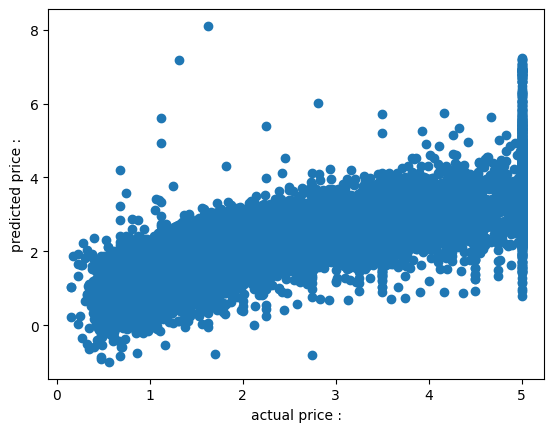

In [43]:
plt.scatter(y_train,training_data_prediction)
plt.xlabel('actual price :')
plt.ylabel('predicted price :')
plt.show()

In [44]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[2.81424673 1.25006917 1.45367217 ... 3.14362113 2.37874928 1.42452394]


In [45]:
score1 = metrics.mean_absolute_error(y_test,test_data_prediction)
score2 = metrics.mean_squared_error(y_test,test_data_prediction)
score3 = np.sqrt(metrics.mean_squared_error(y_test,test_data_prediction))

print(score1)
print(score2)
print(score3)

0.5415616522650654
0.5450798947135779
0.7382952625566399
